## Ugropy power users

In this final section of the tutorial, we will explore some advanced features of
`ugropy` that were not covered in the previous sections. These features are
intended for users who want to customize the behavior of the already
implemented models in `ugropy` or who want to implement their own models.

### Non-optimal solutions

As explained in previous sections, `ugropy` allows you to search for multiple
solutions for the models, but all these solutions are optimal (they use the same
number of groups to represent the molecule). However, it is possible to search for
non-optimal solutions along with the optimal ones. This is useful when you want 
to find all possible combinations of fragments that cover the molecule.
Please note that this feature is intended for research purposes and is not 
recommended for actually modeling molecules.

We can enable this for all `ugropy` models using the `search_nonoptimal`
parameter:

In [1]:
from ugropy import unifac

solutions = unifac.get_groups(
    "9,10-dihydroanthracene",
    search_multiple_solutions=True, # If this is False, search_nonoptimal is ignored
    search_nonoptimal=True,
)

# Three solutions were found:
solutions

We can visualize all the obtained solutions:

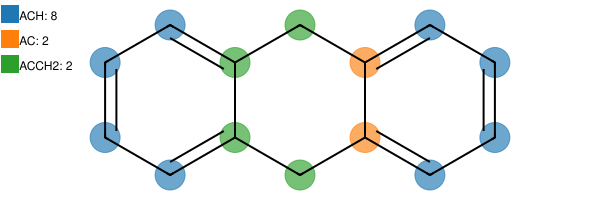

In [2]:
solutions[0].draw(width=600)

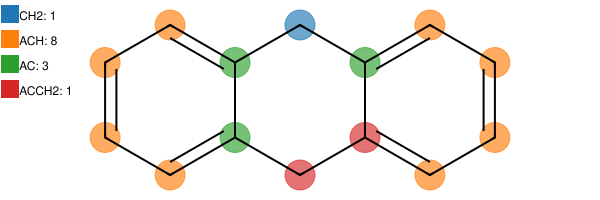

In [3]:
solutions[1].draw(width=600)

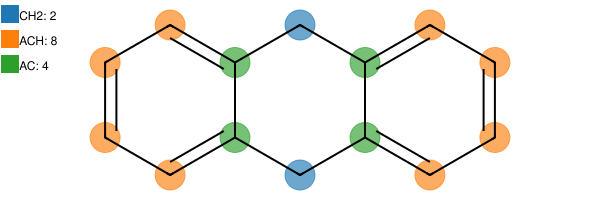

In [4]:
solutions[2].draw(width=600)

If you are an experienced user of UNIFAC-like models, you may notice that the
only "correct" solution is the first one. When non-optimal solutions are
enabled, the algorithm will always find the optimal solutions first, and then
it will search for non-optimal solutions in a "non-optimal" order.

### Changing the default ILP solver

By default, `ugropy` uses the standard CBC solver from the `PuLP` library.
However, `PuLP` supports a wide variety of solvers. Changing the ILP solver can
significantly impact the library's execution time. A great alternative is the
`XPRESS_PY` solver.

First, you must install `XPRESS`:

```shell
pip install xpress
```

Then, you can change the default solver by passing it as an argument:

/home/runner/.local/lib/python3.12/site-packages/pulp/apis/xpress_api.py:751: LicenseWarning: Using the Community license in this session. If you have a full Xpress license, pass the full path to your license file to xpress.init(). If you want to use the FICO Community license and no longer want to see this message, use the following code before using the xpress module:
  xpress.init('/home/runner/.local/lib/python3.12/site-packages/xpresslibs/bin/community-xpauth.xpr')
  model = xpress.problem()
/home/runner/.local/lib/python3.12/site-packages/pulp/apis/xpress_api.py:774: DeprecationWarning: Deprecated in Xpress 9.8: use problem.addCols instead.
  model.addcols(obj, [0] * (len(obj) + 1), [], [], lb, ub, names, ctype)


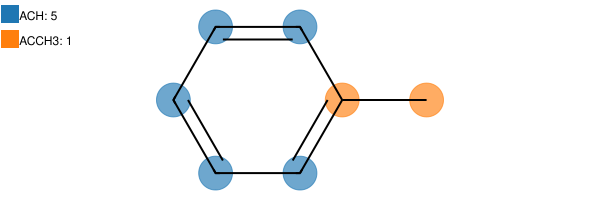

In [5]:
from ugropy import unifac


unifac.get_groups("toluene", solver_arguments={"solver": "XPRESS_PY"}).draw(width=600)

### Understanding model instances and their configuration

`ugropy` is designed using the singleton pattern; therefore, all the models we
have been using throughout this tutorial are instances of the `FragmentationModel` 
class. This class possesses several attributes that can be used to inspect 
the models' information and definitions.

Each model in `ugropy` is composed of two distinct classes:
`FragmentationModel` and `FragmentationResult`.

The `FragmentationModel` class contains all the fundamental information 
about a model, such as its fragment definitions. It serves as the base class 
required to define a minimal model and implements the `get_groups` method. 
The specific models in `ugropy` are not direct instances of this base class, 
but rather instances of subclasses that inherit from it. For example, the 
UNIFAC model is an instance of the `GibbsModel` class (a subclass of 
`FragmentationModel`). The advantage of these subclasses is that they provide 
additional methods (such as multiple-solution filtering). Furthermore, a 
`GibbsModel` requires more detailed fragment information to be instantiated, 
such as the $R$ and $Q$ parameters.

Finally, each `FragmentationModel` returns an instance of its specific 
`FragmentationResult` subclass when the `get_groups` method is called. In the 
case of a `GibbsModel`, the `get_groups` method returns a 
`GibbsFragmentationResult` instance (which inherits from `FragmentationResult`). 
This architectural design allows different models to perform specific 
post-processing tasks after fragment detection. For instance, the 
`GibbsFragmentationResult` class automatically calculates the $R$ and $Q$ values 
of the solution, while the `JobackFragmentationResult` class computes the 
Joback group-contribution properties.

Understanding this architecture is important because it guarantees that while 
all models share the core attributes and methods required by the 
`FragmentationModel` base class, they also offer specialized features 
depending on their specific subclass.

Let's examine the documentation of a base `FragmentationModel` class (you can 
always check the API documentation for the complete list of methods and attributes).

In [6]:
from ugropy import FragmentationModel

help(FragmentationModel)

Help on class FragmentationModel in module ugropy.core.frag_classes.base.fragmentation_model:

class FragmentationModel(builtins.object)
 |  FragmentationModel(subgroups: pandas.DataFrame, allow_overlapping: bool = False, allow_free_atoms: bool = False, fragmentation_result: ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult = <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>) -> None
 |
 |  FragmentationModel class.
 |
 |  All ugropy supported models are an instance of this class. This class must
 |  be inherited to create a new type of FragmentationModel.
 |
 |  Parameters
 |  ----------
 |  subgroups : pd.DataFrame
 |      Model's subgroups. Index: 'group' (subgroups names). Mandatory columns:
 |      'smarts' (SMARTS representations of the group to detect its presense in
 |      the molecule).
 |  allow_overlapping : bool, optional
 |      Whether allow overlapping or not, by default False
 |  allow_free_atoms : bool, optional
 |  

You can instantiate a base `FragmentationModel` class with the minimum
required information.

This class expects a pandas DataFrame (`subgroups` parameter) that contains a 
specific index and a mandatory column. The index, named `group`, contains the 
names of the fragments, and the column, named `smarts`, contains the SMARTS 
patterns of the fragments. 

The class also accepts a boolean parameter called `allow_overlapping`, which 
indicates whether the model allows the detected fragments within the molecule 
to overlap. Similarly, the `allow_free_atoms` argument indicates whether the 
model allows free atoms (atoms not occupied by any group). Finally, it requires 
a `FragmentationResult` class; by default, the base `FragmentationResult` 
class is used.

In the "Getting Started - About the Algorithm" section of the tutorial, we
defined some models by identifying the fragments directly with the RDKit library. 
Now, let's achieve the same result using the `FragmentationModel` class.

The fragments that we previously defined were:

```python
# Definition of the fragments of our model

# Aliphatic CH2
ch2 = Chem.MolFromSmarts("[CX4H2]")

# Aromatic CH
ach = Chem.MolFromSmarts("[cH]")

# Aromatic C without H
ac = Chem.MolFromSmarts("[cH0]")

# Aromatic C bonded with aliphatic CH2
acch2 = Chem.MolFromSmarts("[cH0][CX4H2]")

# List of fragments of our model
fragments = [ch2, ach, ac, acch2]
fragments_names = ["CH2", "ACH", "AC", "ACCH2"]
```

Let's build a DataFrame with this information (later, you can store it as a
.csv file and load it with pandas to reinstantiate the model):

In [7]:
import pandas as pd

from ugropy import FragmentationModel, FragmentationResult


subgroups = pd.DataFrame(
    {
        "group": ["CH2", "ACH", "AC", "ACCH2"],
        "smarts": ["[CX4H2]", "[cH]", "[cH0]", "[cH0][CX4H2]"],
    },
)

subgroups.set_index("group", inplace=True)

subgroups

,smarts
group,
CH2,[CX4H2]
ACH,[cH]
AC,[cH0]
ACCH2,[cH0][CX4H2]


Now, let's instantiate our model:

In [8]:
our_model = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=False,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

We can use this model to fragment a molecule in the same way we used the other
`ugropy` models. The result will be a FragmentationResult instance (you can
check the API documentation for more details on this class). Let's test it with
the same molecule we used in the "About the Algorithm" section of the tutorial.

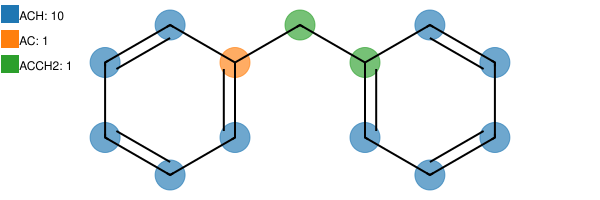

In [9]:
result = our_model.get_groups("c1ccccc1Cc2ccccc2", "smiles")

result.draw(width=600)

This returns the result as a dictionary of group occurrences, using the names 
we defined in our DataFrame as keys:

In [10]:
result.subgroups

{'ACH': 10, 'AC': 1, 'ACCH2': 1}

The specific molecule atoms covered by each fragment can be accessed via the 
`subgroups_atoms` attribute of the `FragmentationResult` instance. This 
attribute is a dictionary where the keys are the fragment names, and the values 
are lists of lists containing the atom indices covered by each occurrence. 
Consequently, the number of nested lists matches the total occurrences of 
that fragment in the molecule.

In [11]:
result.subgroups_atoms

{'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)],
 'AC': [(5,)],
 'ACCH2': [(7, 6)]}

In [12]:
type(result)

ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult

Since we did not allow overlapping in the previous example, the algorithm found
the optimal solution, ensuring that each atom of the molecule was covered by
only one fragment (while using the minimum number of groups).

Let's see what happens if we allow overlapping:

In [13]:
our_model_olap = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=True,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

result_overlapping = our_model_olap.get_groups("c1ccccc1Cc2ccccc2", "smiles")

print(result_overlapping.subgroups)
print(result_overlapping.subgroups_atoms)

{'CH2': 1, 'ACH': 10, 'AC': 2, 'ACCH2': 2}
{'CH2': [(6,)], 'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)], 'AC': [(5,), (7,)], 'ACCH2': [(5, 6), (7, 6)]}


As you can see, because overlapping was enabled, the algorithm directly
returned all detected fragments in the molecule without searching for an
optimal selection. Consequently, some atoms are now covered by multiple
fragments.

Let's inspect the internal attributes of our `our_model` instance. First, we
can access the same parameters we specified during instantiation. Since these
are attributes of the base class, they are available across all models in
`ugropy`.

In [14]:
print("Fragments of the model:")
print(our_model.subgroups)
print("Allow overlapping:", our_model.allow_overlapping)
print("Allow free atoms:", our_model.allow_free_atoms)
print("Fragmentation result class:", our_model.fragmentation_result)

Fragments of the model:
             smarts
group              
CH2         [CX4H2]
ACH            [cH]
AC            [cH0]
ACCH2  [cH0][CX4H2]
Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>


We have an additional, and important, attribute called `detection_mols`:

In [15]:
our_model.detection_mols

{'CH2': <rdkit.Chem.rdchem.Mol at 0x7f2565574120>,
 'ACH': <rdkit.Chem.rdchem.Mol at 0x7f2565574190>,
 'AC': <rdkit.Chem.rdchem.Mol at 0x7f2565574200>,
 'ACCH2': <rdkit.Chem.rdchem.Mol at 0x7f2565574270>}

When you instantiate a model, during initialization, all the fragments defined
in the DataFrame are used to create a dictionary. This dictionary contains the
fragment names as keys, and the corresponding RDKit Mol objects as values,
which are created internally as:

```python
from rdkit import Chem

mol = Chem.MolFromSmarts(smarts)
```

For this reason, all the SMARTS patterns we define must be compatible with the
`RDKit` library. This attribute is used internally by the `get_groups` method
to search for fragments within the molecule. Pre-building these objects avoids
recreating the `RDKit` `Mol` instances every time `get_groups` is called,
significantly optimizing execution time.

As mentioned before, these are the attributes common to any
`FragmentationModel` subclass, but specific subclasses can implement additional
attributes. For example, an instance of the `GibbsModel` class possesses all
the core attributes we just explored, plus several others:

In [16]:
from ugropy import unifac

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", unifac.subgroups)

print("Allow overlapping:", unifac.allow_overlapping)
print("Allow free atoms:", unifac.allow_free_atoms)
print("Fragmentation result class:", unifac.fragmentation_result)
print("Detection mol objects:", unifac.detection_mols)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.gibbs_model.gibbs_result.GibbsFragmentationResult'>
Detection mol objects: {'CH3': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4040>, 'CH2': <rdkit.Chem.rdchem.Mol object at 0x7f25691f40b0>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4120>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4190>, 'CH2=CH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4200>, 'CH=CH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4270>, 'CH2=C': <rdkit.Chem.rdchem.Mol object at 0x7f25691f42e0>, 'CH=C': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4350>, 'ACH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f43c0>, 'AC': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4430>, 'ACCH3': <rdkit.Chem.rdchem.Mol object at 0x7f25691f44a0>, 'ACCH2': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4510>, 'ACCH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f4580>, 'OH': <rdkit.Chem.rdchem.Mol object at 0x7f25691f45f0>, 'CH3OH':

Another example is the `JobackModel` class, which shares the same attributes 
as the base class but also includes an additional attribute called 
`properties_contributions`. This attribute contains the contribution of each 
fragment to the various Joback properties.

In [17]:
from ugropy import joback

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", joback.subgroups)

print("Allow overlapping:", joback.allow_overlapping)
print("Allow free atoms:", joback.allow_free_atoms)
print("Fragmentation result class:", joback.fragmentation_result)
print("Detection mol objects:", joback.detection_mols)

# Commented out to avoid printing a large DataFrame
# print("Properties contributions:", joback.properties_contributions)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.joback.joback_result.JobackFragmentationResult'>
Detection mol objects: {'-CH3': <rdkit.Chem.rdchem.Mol object at 0x7f25691d68f0>, '-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6960>, '>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d69d0>, '>C<': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6a40>, '=CH2': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6ab0>, '=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6b20>, '=C<': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6b90>, '=C=': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6c00>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6c70>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6ce0>, 'ring-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6d50>, 'ring>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6dc0>, 'ring>C<': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6e30>, 'ring=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f25691d6ea

Please refer to the API documentation of each model for more information about
the parameters, attributes, and methods available for each specific class.

### Changing the behavior of an existing model

In certain situations, you might want to alter the behavior of one or a few 
fragments within an existing `ugropy` model. Naturally, modifying the behavior 
of those specific fragments does not justify creating an entirely new model 
from scratch.

This section is inspired by the following `ugropy` GitHub issue:

[https://github.com/ipqa-research/ugropy/issues/41](https://github.com/ipqa-research/ugropy/issues/41)

Although the built-in models in `ugropy` are not intended to be directly mutated 
by the user, we can easily leverage the data inside the model's attributes 
to instantiate a new one with the desired modifications.

In that GitHub issue, the user wanted to modify the behavior of the `ACNH2`
fragment within the UNIFAC model. Specifically, they wanted to enable the 
`ACNH2` fragment to match both `ACNH2` and `ACNH` structures. First, let's 
inspect how the SMARTS pattern for `ACNH2` is originally defined in the UNIFAC 
model:

In [18]:
from ugropy import unifac

unifac.subgroups.loc["ACNH2", "smarts"]

'[cH0][NH2]'

As you can observe, the SMARTS pattern for `ACNH2` is defined as `[cH0][NH2]`
(an aromatic carbon without hydrogen bonded to a nitrogen with two hydrogens).
The molecule provided by the user in the GitHub issue was:

SMILES: CC(=O)NC1=CC=C(O)C=C1

As currently defined in the library, the UNIFAC model will not detect the
`ACNH2` fragment in this molecule because the actual structure present is an
`ACNH` group (an aromatic carbon without hydrogen bonded to a nitrogen with
only one hydrogen). Furthermore, the standard UNIFAC model does not provide an
`ACNH` fragment in its original literature. Let's check what happens:

In [19]:
result = unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{}


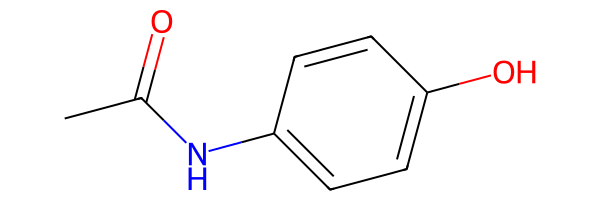

In [20]:
result.draw(width=600)

As expected, `ugropy` fails to obtain the fragmentation of the molecule because 
the `NH` group is not covered by any available fragment, leaving free atoms 
unaccounted for.

First, let's leverage our knowledge from the previous section to retrieve the 
complete data from the UNIFAC model's attributes.

First, the SMARTS DataFrame:

In [21]:
subgroups = unifac.subgroups.copy()

subgroups

,smarts,molecular_weight
group,,
CH3,[CX4H3],15.03500
CH2,[CX4H2],14.02700
CH,[CX4H],13.01900
C,[CX4H0],12.01100
CH2=CH,[CH2]=[CH],27.04600
...,...,...
NCO,[NX2H0]=[CX2H0]=[OX1H0],42.01700
(CH2)2SU,[CH2]S(=O)(=O)[CH2],92.11620
CH2CHSU,[CH2]S(=O)(=O)[CH],91.10840


Since UNIFAC is a `GibbsModel`, we also need to retrieve the fragments
information to instantiate a new model:

In [22]:
subgroups_info = unifac.subgroups_info.copy()

subgroups_info

,subgroup_number,main_group,R,Q
group,,,,
CH3,1,1,0.9011,0.848
CH2,2,1,0.6744,0.540
CH,3,1,0.4469,0.228
C,4,1,0.2195,0.000
CH2=CH,5,2,1.3454,1.176
...,...,...,...,...
NCO,109,51,1.0567,0.732
(CH2)2SU,118,55,2.6869,2.120
CH2CHSU,119,55,2.4595,1.808


Now, lets modify the SMARTS pattern of the `ACNH2` fragment to match both
`ACNH2` and `ACNH` structures and instantiate a new model with the modified
SMARTS pattern:

In [23]:
from ugropy import GibbsModel

# Change directly the SMARTS column for the ACNH2 fragment
# now the aromatic carbon could be bonded to either NH2 or NH.
subgroups.loc["ACNH2", "smarts"] = "[cH0][NH2,NH]"

new_unifac = GibbsModel(
    subgroups=subgroups,
    subgroups_info=subgroups_info,
    calculate_r_q=True
)

Now, lets try to fragment the same molecule with our modified UNIFAC model:

In [24]:
result = new_unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{'ACH': 4, 'ACOH': 1, 'CH3CO': 1, 'ACNH2': 1}


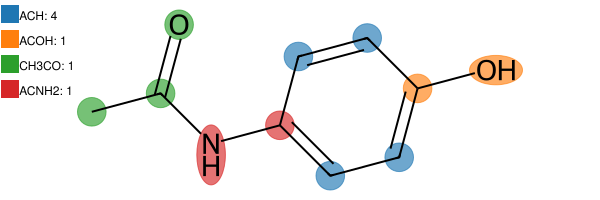

In [25]:
result.draw(width=600)

Success! Now, the `ACNH` structure present in the molecule is successfully
detected under the `ACNH2` fragment definition.

### Understanding which fragment is not being detected

There is an additional technique available for all models that helps you 
determine whether a specific fragment is being successfully detected within a 
molecule. This short section serves as a diagnostic bridge between modifying an 
existing model and creating your own from scratch.

To explore this, we can use the `instantiate_mol_object` function from
`ugropy`. This function processes any of the molecular identifiers supported by
the `get_groups` method to return an RDKit Mol object.

Additionally, all `FragmentationModel` instances implement the
`detect_fragments` method. While this method is typically executed internally
during the `get_groups` call, we can call it explicitly to inspect which
fragments are captured during the initial direct detection step of the
algorithm.

Let's check the `instantiate_mol_object` docstring:

In [26]:
from ugropy import instantiate_mol_object

help(instantiate_mol_object)

Help on function instantiate_mol_object in module ugropy.core.get_rdkit_object:

instantiate_mol_object(identifier: Union[str, rdkit.Chem.rdchem.Mol], identifier_type: str = 'name') -> rdkit.Chem.rdchem.Mol
    Instantiate a RDKit Mol object from molecule's name, SMILES or mol.

    In case that the input its already a RDKit Mol object, the function will
    return the input object.

    Parameters
    ----------
    identifier : str or rdkit.Chem.rdchem.Mol
        Identifier of a molecule (name, SMILES or rdkit.Chem.rdchem.Mol).
        Example: hexane or CCCCCC for name or SMILES respectively.
    identifier_type : str, optional
        Use 'name' to search a molecule by name, 'smiles' to provide the
        molecule SMILES representation or 'mol' to provide a
        rdkit.Chem.rdchem.Mol object, by default "name".

    Returns
    -------
    rdkit.Chem.rdchem.Mol
        RDKit Mol object.



Now, let's test this with the molecule from the previous example, comparing the
original UNIFAC model against our modified version (`new_unifac`). First, using
the original model:

In [27]:
mol = instantiate_mol_object("CC(=O)NC1=CC=C(O)C=C1", "smiles")

unifac.detect_fragments(mol)

{'CH3_0': (0,),
 'ACH_0': (5,),
 'ACH_1': (6,),
 'ACH_2': (9,),
 'ACH_3': (10,),
 'AC_0': (4,),
 'AC_1': (7,),
 'OH_0': (8,),
 'ACOH_0': (7, 8),
 'CH3CO_0': (0, 1, 2)}

As you can observe, the `ACNH2` fragment is missing from the detections. Now, 
let's run the same check using our modified UNIFAC instance:

In [28]:
new_unifac.detect_fragments(mol)

{'CH3_0': (0,),
 'ACH_0': (5,),
 'ACH_1': (6,),
 'ACH_2': (9,),
 'ACH_3': (10,),
 'AC_0': (4,),
 'AC_1': (7,),
 'OH_0': (8,),
 'ACOH_0': (7, 8),
 'CH3CO_0': (0, 1, 2),
 'ACNH2_0': (4, 3)}

Now, the `ACNH2` fragment is successfully detected. 

The numbers inside each tuple represent the atom indices occupied by that specific 
detection. The numeric suffix of each fragment key indicates the distinct occurrences 
of that fragment type. For example:

- ACH_**0**: (5,)

- ACH_**1**: (6,)

- ACH_**2**: (9,)

- ACH_**3**: (10,)

This indicates that our molecule contains four total `ACH` fragments, each 
occupying different atoms (note that implicit hydrogens are never counted as independent 
atoms in the RDKit library).

### User defined fragmentation models

This section will be brief, as it involves advanced Python concepts that are 
beyond the scope of this tutorial and will not be explained from scratch.

If you want to create your own specialized category of `FragmentationModel`, 
you need to master two key elements. First, you must learn the SMARTS notation 
to define your fragments (covered as a brief introduction in the next section). 
Second, you need to understand how to extend the behavior of the base 
`FragmentationModel` and `FragmentationResult` classes via inheritance:

```python
from ugropy import FragmentationModel, FragmentationResult


class MyFragModel(FragmentationModel):
    ...


class MyFragModelResult(FragmentationResult):
    ...
```

Maybe you want to create a model that only fragments the molecules without
doing anything else. In that case, you can simply instantiate the base
`FragmentationModel` class with the required information as we have seen in the
previous section: "Understanding model instances and their configuration".

On the other hand, maybe you want to create a model that, after detecting the
fragments, performs additional operations with them, such as property
estimations. The best approach at this point is to check the `ugropy` source
code and learn from it directly (it is not that much code, I promise!).

First, explore the two base classes to understand their core architecture:

- [FragmentationModel](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/base/fragmentation_model.py)
- [FragmentationResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/base/fragmentation_result.py)

Then, you can look at a straightforward extension of the base class, the
`GibbsModel` and its corresponding result class:

- [GibbsModel](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/gibbs_model/gibbs_model.py)
- [GibbsResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/gibbs_model/gibbs_result.py)

In the `GibbsModel` definition, you will see how the `__init__` method is
**overridden** to customize its docstring and incorporate new parameters.
Moreover, additional validation filters are implemented in this subclass (while
those already present in `FragmentationModel` are automatically inherited). In
`GibbsResult`, you can check how the calculation of the $R$ and $Q$ values is
triggered once the fragmentation result is received.

Finally, you can inspect a more complex implementation, specifically its result
class, `JobackResult`. While the underlying logic remains the same, it serves
as a more advanced example that demonstrates how `ugropy` internally integrates
the `Pint` library for unit management:

- [JobackFragmentationResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/joback/joback_result.py)

Every class definition is available in the repository, providing a clear
blueprint to build your own custom models.

Finally, there is an optional method in the `FragmentationModel` base class 
that we haven't discussed yet: `mol_preprocess`.

This method is executed internally during the `get_groups` call. The algorithm
first creates the RDKit Mol object via `instantiate_mol_object` and then passes
that object directly to `mol_preprocess`. By default, this method returns the
molecule unchanged. However, if you inherit from the base class, you can
**override** it to leverage RDKit's full capabilities to modify the nature of
the molecule before any fragment detection takes place. For instance, you could
force specific rings to be considered aromatic (or non-aromatic), sanitize
functional groups, or perform advanced structural manipulations tailored to
your needs.

That being said, for the majority of use cases, you won't need to touch this
method. Most fragmentation challenges can be resolved simply by defining your
SMARTS patterns correctly!

### SMARTS tutorial

This is the final piece of the puzzle you need to master to define your own 
fragmentation models. Before diving in, a quick word of caution: this is not a 
trivial task. It requires not only a solid grasp of the SMARTS syntax but also 
an understanding of how fragment definitions can be deeply dependent on the 
thermodynamic model itself (we will explore some examples of this later).

This brief tutorial is based on the official Daylight documentation, where you 
can find all the fundamental directives of the SMARTS syntax:

- [Daylight SMARTS Theory](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html)

Additionally, RDKit supports certain extended SMARTS features, such as Chemaxon
extended SMARTS link nodes, which can be incredibly useful for complex
macro-structures:

- [Chemaxon Extended SMARTS](https://docs.chemaxon.com/latest/formats_chemaxon-extended-smiles-and-smarts-cxsmiles-and-cxsmarts.html)

The first golden rule is: **you must strictly follow the SMARTS syntax that
RDKit understands**. Furthermore, you can inspect the production-ready SMARTS
definitions for all built-in models directly in the `ugropy` repository. While
perhaps not exhaustive, they serve as a learning resource:

- [Groups CSV in Repository](https://github.com/ipqa-research/ugropy/tree/main/ugropy/groupscsv)

If you want to open them on excel/LibreOffice, you can download the CSV files
directly from the repository and open them with your preferred spreadsheet
software. The column separator is the character `|` (sorry, I didn't like
spaces and all other characters are already used in the SMARTS syntax). Also,
you may find the character `?` at the beginning of some SMARTS patterns. This
character is used to indicate commented lines, which are ignored.

Ultimately, the performance of your custom model will be strictly dictated by
how precisely you define your fragments, defining "performance" here as: the
model detects the exact fragments I want it to detect for this molecule. For
that, testing is crucial (refer to the test book to find some examples of
molecules with their SMILES representations).

#### The basics

In SMARTS (as in SMILES notation), we define chemical structures using specific 
structural or logical patterns. These structures are read and evaluated from 
left to right. For example, consider the n-hexane molecule:

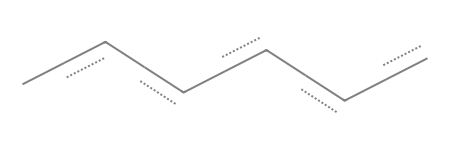

In [29]:
from rdkit import Chem

smt = Chem.MolFromSmarts("CCCCCC")

smt

Here, we are defining six aliphatic carbons "bonded" one after the other. I
emphasize "bonded" because we are not explicitly specifying the type of bond
yet. Let's explicitly define that these connections are single bonds:

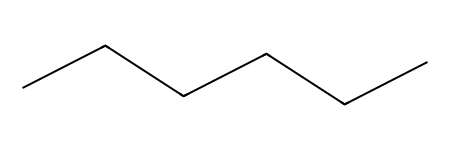

In [30]:
smt = Chem.MolFromSmarts("C-C-C-C-C-C")

smt

See how the drawing changes? Now we have explicitly defined six aliphatic
carbons connected by single bonds.

Let's add a double bond in the middle:

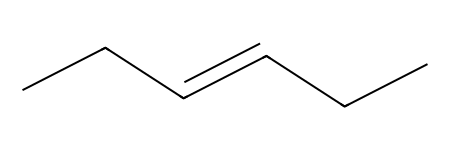

In [31]:
smt = Chem.MolFromSmarts("C-C-C=C-C-C")

smt

Now, a double bond is specified between positions 3 and 4. As a side note,
implicit hydrohens are automatically accounted for in this simplified notation
until the standard valence of the atom is satisfied.

This approach feels very similar to writing standard SMILES. However, when
defining robust SMARTS patterns for group contribution models, we usually
need to enforce the exact connectivity of an atom and specify precisely how
many hydrogens are bonded to it. Let's completely and explicitly define the
n-hexane molecule using strict SMARTS syntax:

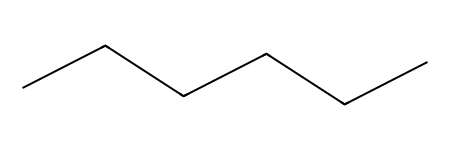

In [32]:
smt = Chem.MolFromSmarts("[CX4H3]-[CX4H2]-[CX4H2]-[CX4H2]-[CX4H2]-[CX4H3]")

smt

Nothing seems to change in the visual representation, but we have introduced a
lot of new notation. Let's break it down step by step. 

First, the brackets: in SMARTS notation, brackets `[]` indicate that an atom is
being defined by specific logical properties or constraints. The structure
`[CX4H3]` is telling the engine: "This is an aliphatic carbon (`C`) bonded to
four total atoms (`X4`), and exactly three of those four connections are
hydrogens (`H3`, which sets the explicit hydrogen count)."

Similarly, with `[CX4H2]`, we are specifying an aliphatic carbon bonded to four
total atoms, two of which must be hydrogens.

Therefore, when we write `[CX4H3]-[CX4H2]`, we are saying—and pardon the
redundancy: *"An aliphatic carbon with a total connectivity of 4 and three
hydrogens is bonded via a single covalent bond to an aliphatic carbon with a
total connectivity of 4 and two hydrogens."*

Let's define this small substructure (`[CX4H3]-[CX4H2]`) and search for it
within the n-hexane molecule. Naturally, we should find exactly two
occurrences:


In [33]:
hexane = Chem.MolFromSmiles("CCCCCC") # n-hexane

smt = Chem.MolFromSmarts("[CX4H3]-[CX4H2]")

matches = hexane.GetSubstructMatches(smt)

print("Matches:", matches)
print("Number of matches:", len(matches))

Matches: ((0, 1), (5, 4))
Number of matches: 2


As expected, we found two of these substructures at atom indices (0, 1) and (5,
4). 

At this point, an attentive reader might think:

"Well, if I am already enforcing the connectivity of the carbons (`X4`) and
the exact number of hydrogens, explicitly defining the single bond in this
particular case seems redundant."

And you would be absolutely right! In logical terms, these two definitions are
completely equivalent:

* `[CX4H3]-[CX4H2]`
* `[CX4H3][CX4H2]`

But be careful: if you don't restrict the total connectivity of an atom, it can
lead to unexpected false positives. Let's analyze the pattern `[CH2]`. Here, we
are enforcing the hydrogen count but leaving the total connectivity open. It
works perfectly fine for n-hexane:

In [34]:
smt = Chem.MolFromSmarts("[CH2]")

hexane = Chem.MolFromSmiles("CCCCCC") # n-hexane

matches = hexane.GetSubstructMatches(smt)

matches

((1,), (2,), (3,), (4,))

However, let's see what happens when we test this exact same pattern against
the propene molecule:

((0,),)


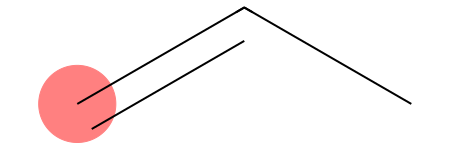

In [35]:
propene = Chem.MolFromSmiles("C=CC") # propene

smt = Chem.MolFromSmarts("[CH2]")

matches = propene.GetSubstructMatches(smt)

print(matches)

propene

We found a detection! And of course we did: the `[CH2]` pattern simply asks for
*any aliphatic carbon with exactly two hydrogens*. In propene, the terminal
alkene carbon (position 2 or 0 depending on RDKit indexing) satisfies this
exact condition. 

If your thermodynamic model needs to distinguish between an unreactive
aliphatic alkane group and an olefinic group, a generic pattern like `[CH2]`
will ruin your fragmentation parameters. This is precisely where the **SMARTS
craftsmanship** comes into play. 

Let's design two distinct patterns to cleanly separate both cases:

In [36]:
# Alkane CH2 (sp3 carbon bonded to 4 atoms total)
alkane_ch2 = Chem.MolFromSmarts("[CX4H2]")

# Alkene CH2 (sp2 carbon bonded to 3 atoms total)
alkene_ch2 = Chem.MolFromSmarts("[CX3H2]") 

print("Hexane alkane CH2 matches:", hexane.GetSubstructMatches(alkane_ch2))
print("Hexane alkene CH2 matches:", hexane.GetSubstructMatches(alkene_ch2))

print("Propene alkane CH2 matches:", propene.GetSubstructMatches(alkane_ch2))
print("Propene alkene CH2 matches:", propene.GetSubstructMatches(alkene_ch2))

Hexane alkane CH2 matches: ((1,), (2,), (3,), (4,))
Hexane alkene CH2 matches: ()
Propene alkane CH2 matches: ()
Propene alkene CH2 matches: ((0,),)


While evaluating structures from left to right works perfectly for linear
chains, chemistry is full of branched architectures. Using purely linear logic
makes it impossible to define non-linear molecules. To solve this, SMARTS
introduces **parentheses**.

Consider the following pattern:

`[CX4H3][CX4H2]([OH])[CX4H3]`

In chemical terms, we are defining:

* `[CX4H3]`: An aliphatic carbon with four connections and three hydrogens ($\text{-CH}_3$).
* `[CX4H2]`: An aliphatic carbon with four connections and two hydrogens ($\text{-CH}_2\text{-}$ before branching).
* `[OH]`: A hydroxyl group.

The structure can be read as follows: We have a $\text{-CH}_3$ group bonded to
a carbon, which is simultaneously bonded to both an $\text{-OH}$ group and
another $\text{-CH}_3$ group. Let's build and render this structure in RDKit:

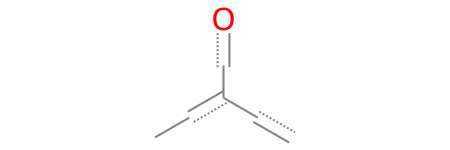

In [37]:
smt = Chem.MolFromSmarts('[CX4H3][CX4H2]([OH])[CX4H3]')

smt

The golden rule for branching is: **any atom or chain written inside
parentheses is always bonded to the atom immediately to its left** (in this
case, the `[CX4H2]` carbon).

If we want to explicitly specify every single bond in this branched structure,
notice carefully where the bond dashes `-` must be placed:

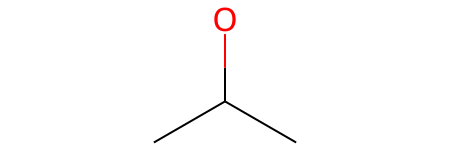

In [38]:
smt = Chem.MolFromSmarts('[CX4H3]-[CX4H2](-[OH])-[CX4H3]')

smt

What happens if we have multiple branches bonded to the same central atom? In
that case, we simply append another set of parentheses consecutive to the first
one:

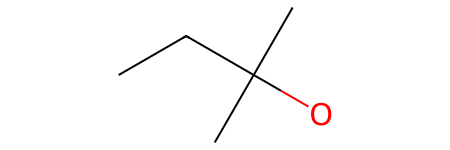

In [39]:
# A central CH2 bonded to an -OH branch and a -CH2-CH3 branch
molecule = Chem.MolFromSmarts("[CH3]-[CH2](-[OH])(-[CH2]-[CH3])-[CH3]")

molecule

Now, the central `[CX4H2]` carbon is simultaneously bonded to two distinct
branches: one containing a hydroxyl group (`-[OH]`) and another containing an
ethyl chain (`-[CX4H2]-[CX4H3]`). 

The rule remains unshakable: **all parentheses are attached directly to the atom immediately to their left**.
Furthermore, this logic is perfectly scalable, meaning you can nest parentheses
inside other parentheses to build as many complex sub-branches as your
thermodynamic model requires!

Finally, to conclude the core basics of SMARTS syntax, we have **rings**. This is 
incredibly useful for defining specific aromatic or aliphatic cyclic fragments. 

How do we define a ring? We use numbers. By labeling two separate atoms with the 
same digit, we instruct the engine to form a bond between them, effectively 
bridging the gap and bypassing the strict left-to-right progression. For example, 
a cyclohexane ring can be defined as follows:

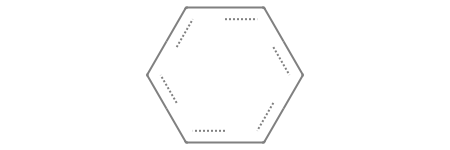

In [40]:
# Check the first and the last [CX4H2] have a 1, they are going to be bonded
smt = Chem.MolFromSmarts("[CX4H2]1[CX4H2][CX4H2][CX4H2][CX4H2][CX4H2]1")

smt

If your molecule contains multiple rings, you can use different numbers to 
define each individual cycle. For example, consider this bicyclic system:

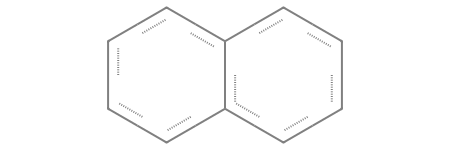

In [41]:
# A bicyclic system combining a 6-membered and a 5-membered ring
smt = Chem.MolFromSmarts("[CX4H2]1[CX4H2][CX4H]2[CX4H2][CX4H2][CX4H2][CX4H2][CX4H]2[CX4H2][CX4H2]1")

smt

Let's carefully analyze where the ring labels are placed to understand the connectivity:

```shell
[CX4H2] 1 [CX4H2][CX4H] ([CX4H2][CX4H2][CX4H2][CX4H2] 2 ) [CX4H] 2 [CX4H2][CX4H2] 1
```

Here is how the engine interprets it:
* The labels **1** open and close the main 6-membered ring.
* Inside that main ring, we encounter the first bridgehead carbon (`[CX4H]`),
  which opens the second ring (in the parenthesis).
* The structure then continues along a linear chain of four `[CX4H2]` groups.
* At the end of this chain the final `[CX4H2]` is labeled with a **2**, the
  second bridgehead carbon (`[CX4H]`) is also labeled with a **2**, closing the
  second ring and fusing the two cycles together.

(Note: Notice that the bridgehead carbons are defined as `[CX4H]` instead of
`[CX4H2]`, because they are bonded to three heavy atoms total, leaving room for
only one hydrogen).

#### Logical operators, ring constraints, and aromaticity

What happens when we want to define a fragment that must only be detected if it 
is part of an aliphatic ring? To achieve this level of control, we need to utilize 
SMARTS logical expressions:

* `!`: "NOT" (highest precedence)
* `&`: "AND" (high precedence)
* `,`: "OR" (low precedence)
* `;`: "AND" (lowest precedence)

Precedence here follows the exact same concept as in any programming language: 
operators are evaluated in a specific order. High-precedence operators are 
resolved first. It is important to note that **you cannot use parentheses to group 
logical operations** in SMARTS, because parentheses are strictly reserved for 
chemical branching.

To illustrate how precedence changes the evaluation order, consider the operands 
$A$, $B$, and $C$:

**A&B,C**

This expression means "either ($A$ AND $B$), or $C$", which translates
mathematically to $(A \wedge B) \vee C$. The high-precedence `&` operator is
evaluated first.

On the other hand:

**A;B,C**

This expression means "$A$ AND ($B$ or $C$)", which translates mathematically
to $A \wedge (B \vee C)$. The low-precedence `;` operator is evaluated last,
effectively binding the entire "OR" block that precedes it.

Now, imagine you want to define two different $-\text{CH}_2-$ fragment types:
one that must be part of an aliphatic ring (like in cyclohexane) and another
that must strictly belong to an open chain (like in n-hexane). We can cleanly
separate them using the ring membership primitive `R` combined with our logical
operators:

In [42]:
cyclohexane = Chem.MolFromSmiles("C1CCCCC1") # Cyclohexane
hexane = Chem.MolFromSmiles("CCCCCC")        # n-Hexane

# CH2 must NOT be part of a ring
ch2_chain = Chem.MolFromSmarts("[CX4H2;!R]")

# CH2 MUST be part of a ring
ch2_ring = Chem.MolFromSmarts("[CX4H2;R]")

print("Cyclohexane ring CH2 matches:", cyclohexane.GetSubstructMatches(ch2_ring))
print("Cyclohexane chain CH2 matches:", cyclohexane.GetSubstructMatches(ch2_chain))
print("Hexane ring CH2 matches:", hexane.GetSubstructMatches(ch2_ring))
print("Hexane chain CH2 matches:", hexane.GetSubstructMatches(ch2_chain))

Cyclohexane ring CH2 matches: ((0,), (1,), (2,), (3,), (4,), (5,))
Cyclohexane chain CH2 matches: ()
Hexane ring CH2 matches: ()
Hexane chain CH2 matches: ((1,), (2,), (3,), (4,))


In the expression `[CX4H2;!R]`, the engine interprets the logic as: "This is
an aliphatic carbon with a total connectivity of 4 and exactly two hydrogens,
**AND** it is **NOT** part of a ring." The `!` operator negates the `R`
primitive, ensuring no cyclic carbons are matched.

Conversely, in the expression `[CX4H2;R]`, we are enforcing the opposite
constraint: "This is an aliphatic carbon with a total connectivity of 4 and
exactly two hydrogens, **AND** it **MUST** be part of a ring."

You can also specify the exact size of the ring by using a numeric value after
the lowercase `r` primitive. For example, `[CX4H2;r5]` will strictly match
aliphatic carbons that are part of a 5-membered ring:

In [43]:
cyclopentane = Chem.MolFromSmiles("C1CCCC1") # cyclopentane

ch2_5ring = Chem.MolFromSmarts("[CX4H2;r5]") # CH2 must be part of a 5-membered ring

print("Cyclopentane 5-membered ring CH2 matches:", cyclopentane.GetSubstructMatches(ch2_5ring))
print("cyclohexane 5-membered ring CH2 matches:", cyclohexane.GetSubstructMatches(ch2_5ring))

Cyclopentane 5-membered ring CH2 matches: ((0,), (1,), (2,), (3,), (4,))
cyclohexane 5-membered ring CH2 matches: ()


Note the lowercase `r5` used to indicate the ring size. If you accidentally use
an uppercase `R5`, the meaning changes completely: the engine will search for a
`CX4H2` carbon that belongs to **five different rings simultaneously**.

Finally, how do we define an aromatic fragment? In many cases, you don't even
need explicit logical operators for this. Instead, you can simply use the
**lowercase** atom primitives to indicate aromaticity. 

For example, `[cH]` defines an aromatic carbon with exactly one hydrogen, while
`[cH0]` defines an aromatic carbon with no hydrogens. In SMARTS (and SMILES),
lowercase atom symbols always denote aromatic atoms, whereas uppercase symbols
specify aliphatic ones.

By combining what we have learned so far, we can build highly specific filters.
For instance, if you need to target an aromatic carbon with one hydrogen inside
an 8-membered ring, you can write: `[cH;r8]`. 

* `[cH0;R1]` may seem redundant at first glance, since an aromatic atom is by
  definition always part of a ring system. However, if your model needs to
  strictly distinguish peripheral aromatic carbons from those at a ring fusion,
  enforcing the `R1` constraint becomes mandatory to prevent
  cross-contamination.
* `[cH0;R2]` is **NOT redundant**: This pattern specifically targets an
  aromatic carbon with no hydrogens that is shared by **exactly two different
  rings simultaneously** (a bridgehead fusion carbon).

Let's visualize this distinction using a naphthalene:

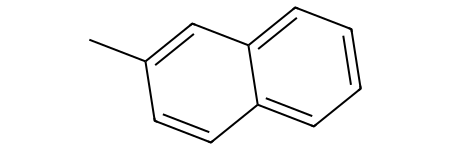

In [44]:
ac_onering = Chem.MolFromSmarts("[cH0;R1]") # Aromatic carbon only in one ring
ac_tworings = Chem.MolFromSmarts("[cH0;R2]") # Aromatic carbon on two rings simultaneously

molecule = Chem.MolFromSmiles("CC1=CC2=C(C=CC=C2)C=C1") # Naphthalene

molecule

With the fragments we have defined, we can differentiate between the different
aromatic carbons with no hydrogens:

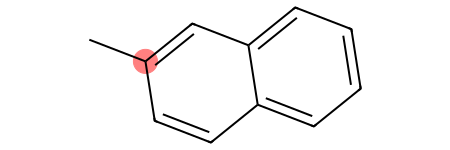

In [45]:
molecule.GetSubstructMatches(ac_onering)

molecule

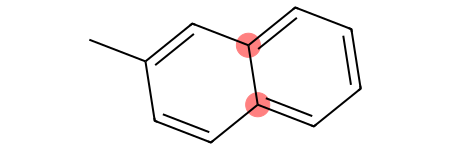

In [46]:
molecule.GetSubstructMatches(ac_tworings)

molecule

Finally, it is possible to define a pattern that matches an element regardless
of whether it is aliphatic or aromatic. This is extremely powerful for
generalization and can be applied to any element in the periodic table. 

To define a generic element, you use the `#` primitive followed by its atomic
number. For instance, carbon is represented by `#6`. Every other constraint we
have learned so far (connectivity, hydrogen count, ring constraints) remains
fully applicable:

* `[#6H]`: A carbon atom (either aliphatic or aromatic) with an unspecified total connectivity, but possessing exactly one hydrogen.
* `[#6X3H]`: A carbon atom (either aliphatic or aromatic) with a total connectivity of 3 and exactly one hydrogen.
* `[#7X3H2]`: A nitrogen atom (either aliphatic or aromatic) with a total connectivity of 3 and exactly two hydrogens.

#### More complex logical patterns and recursive SMARTS

`ugropy` requires you to provide a single, unique SMARTS pattern for each
distinct fragment. For that reason, isolating complex groups requires a
combination of creativity and advanced logic to ensure RDKit identifies
*exactly* the atoms belonging to that fragment, without accidentally matching
the surrounding environment.

Let's inspect a real-world example from `ugropy`. The Dortmund UNIFAC model
differentiates between three different types of hydroxyl groups: primary,
secondary, and tertiary.

In [47]:
from ugropy import dortmund

# Let's inspect the SMARTS for Dortmund UNIFAC OH subgroups
dortmund.subgroups.loc[["OH (P)", "OH (S)", "OH (T)"], "smarts"].to_list()

['[OH;$([OH][CX4H0]([!#6])([!#6])[#6]),$([OH][CX4H]([!#6])[#6]),$([OH][CX4H2][#6]),$([OH][CX3H]=[#6]),$([OH][CX3H0](=[#6])[!#6]),$([OH][CX2]#[#6])]',
 '[OH;$([OH][CX4H0]([!#6])([#6])[#6]),$([OH][CX4H]([#6])[#6]),$([OH][CX3H0](=[#6])[#6])]',
 '[OH;$([OH][#6]);$([OH][CX4H0]([#6])([#6])[#6])]']

This is where things get interesting because we are introducing a highly 
advanced notation. 

Let's dissect the **tertiary hydroxyl group** (`OH (T)`). By definition, a
tertiary hydroxyl is an $-\text{OH}$ group bonded to a tertiary carbon (a
carbon bonded to three other carbon atoms). 

Here is the tricky part for `ugropy`: we only want to match and count the
$-\text{OH}$ group itself, not the carbons that it is attached to. 

If we try to define it using the basic linear and branching syntax we learned
before, we might instinctively write something like this:

`[OH][#6]([#6])([#6])([#6])`

While it is chemically intuitive—an $-\text{OH}$ group bonded to a carbon that
is simultaneously bonded to three other carbons—if we feed this pattern to
RDKit, the engine will return a match that includes **all five atoms** in that
cluster. 

Let's see this issue in action with a branched alcohol:

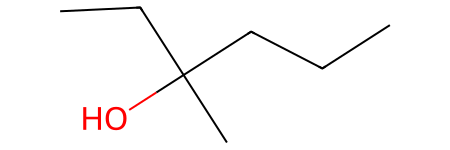

In [48]:
molecule = Chem.MolFromSmiles("OC(CCC)(C)(CC)")

molecule

There we clearly have a tertiary hydroxyl group, let try to search for matches:

Naive matches: ((0, 1, 2, 5, 6),)


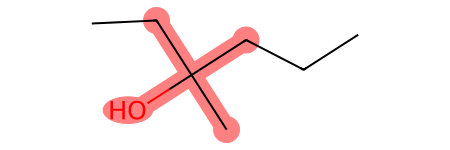

In [49]:
smt_naive = Chem.MolFromSmarts("[OH][#6]([#6])([#6])([#6])")

print("Naive matches:", molecule.GetSubstructMatches(smt_naive))

molecule

Of course, the definitions currently in `ugropy` are far from perfect. However,
by critiquing my own past implementations, we can uncover some incredibly
valuable lessons. The tertiary hydroxyl group is defined in `ugropy` as
follows:

`[OH;$([OH][#6]);$([OH][CX4H0]([#6])([#6])[#6])]`

First, let's look at the outer brackets `[]` enclosing the entire structure. As
we established earlier, brackets allow us to define a single target atom using
specific logical constraints. Up until now, we have restricted atoms by their
aliphatic/aromatic nature, total connectivity, hydrogen count, or ring status.
Now, we are introducing a new superpower: **Recursive SMARTS**.

When building a complex pattern like this from scratch, you should always start
by writing the outer brackets:

`[]`

Next, ask yourself: *What single atom am I actually trying to isolate and count?* Since only the hydroxyl group should be counted when this fragment is matched, our 
primary target is the `OH` group. So, we place it inside:

`[OH]`

Now, we can append our environmental constraints. A **Recursive SMARTS**
expression allows us to specify a structural pattern that must exist around our
target atom *without* actually matching or "claiming" those neighboring atoms.
This is done using the `$()` syntax, joined by our low-precedence AND (`;`)
operator:

`[OH;$()]`

This translates to: "Match a hydroxyl group AND (`;`) ensure that this exact
oxygen is part of the structural environment described inside the parenthesis
`$()`."

The first recursive condition in the `ugropy` pattern is:

`[OH;$([OH][#6])]`

Here, we are saying: "Match a hydroxyl group, but only if it is part of a
larger `[OH][#6]` environment (meaning it must be directly bonded to a carbon
of any nature)."

We can chain as many of these recursive conditions as we need by using
additional low-precedence AND (`;`) operators. This brings us to the full
`ugropy` expression:

`[OH;$([OH][#6]);$([OH][CX4H0]([#6])([#6])[#6])]`

For the match to be successful, our target `OH` must now *also* satisfy this
second environmental checkpoint:

`$([OH][CX4H0]([#6])([#6])[#6])`

Which explicitly states: "The hydroxyl group must be part of an environment
where it is bonded to an aliphatic carbon with a total connectivity of 4 and
zero hydrogens (`[CX4H0]`), which in turn is bonded to three other carbons of
any nature (`[#6]`)."

**Time for some self-critique!** Looking back at my past code, the first
condition (`$([OH][#6])`) is kind of redundant. Why? Because the second, much
stricter condition already mandates that the `OH` must be bonded to a carbon.
If it satisfies the second environment, it automatically satisfies the first
one. 

But as I mentioned, the definitions in `ugropy` are a work in progress—and
making (and analyzing) these redundant steps is exactly how we master SMARTS
craftsmanship!

Let's use this pattern to search for tertiary hydroxyl groups in the previous
molecule:

Tertiary hydroxyl groups: ((0,),)


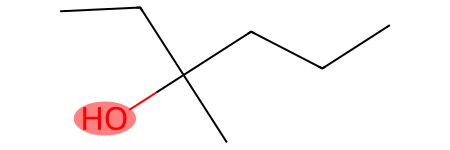

In [50]:
molecule = Chem.MolFromSmiles("OC(CCC)(C)(CC)")

smt = Chem.MolFromSmarts("[OH;$([OH][#6]);$([OH][CX4H0]([#6])([#6])[#6])]")

print("Tertiary hydroxyl groups:", molecule.GetSubstructMatches(smt))

molecule


Now, let's look at one final example that demonstrates how the presence of
*other* groups within a fragmentation model can heavily influence how you
design the logic of a single fragment.

The fragment in question seems fairly simple: the classic UNIFAC **ketone fragment** (`CH3CO`). This group consists of a methyl carbon bonded to a carbonyl carbon (a carbon with zero hydrogens, double-bonded to an oxygen). The pattern must match exactly those two carbons and the oxygen atom. 

It seems easy enough. Let's build it directly and intuitively:

`[CX4H3][CX3H0]=O`

And basically, that's it! It looks flawless. However, let's see how it is
actually defined in `ugropy`:

In [51]:
from ugropy import unifac


unifac.subgroups.loc["CH3CO", "smarts"]

'[CH3][CH0;!$(C(-[O,NH2,$([NH][CH3]),$([NH][CH2]),$([NH0]([CH3])[CH3]),$([NH0]([CH3])[CH2]),$([NH0]([CH2])[CH2])])=O)]=O'

Well, what a masterpiece of a mess! Let's break down what is happening here.
First, let's look at the straightforward components of this beast:

`[CH3][CH0;!$(C(-[O,NH2,$([NH][CH3]),$([NH][CH2]),$([NH0]([CH3])[CH3]),$([NH0]([CH3])[CH2]),$([NH0]([CH2])[CH2])])=O)]=O`

We can dissect it into three main parts:
* `[CH3]`: The methyl group. Simple enough. This is directly bonded to the logical nightmare in the middle.
* `[CH0; with a lot of conditions]`: The carbonyl carbon, which contains all the protective constraints.
* `=O`: The double bond connecting the carbonyl carbon to its oxygen.

The entire challenge lies in decoding the environmental conditions imposed on that central carbonyl carbon:

`[CH0;!$(C(-[O,NH2,...])=O)]`

Here, we are applying the structural filter we just learned: `[CH0;!$()]`
("This is a carbonyl carbon, **AND IT MUST NOT** match the following
environments"). 

Essentially, we are telling RDKit: *"It is a carbonyl, but it cannot be bonded
to X, or Y, or Z."* Let's look at what we are excluding:

* `-[O...]`: The carbonyl carbon must **not** have a single bond to an oxygen.
  If it did, this group would actually be an **ester** or a **carboxylic
  acid**. We definitely don't want a ketone pattern falsely triggering there.
* `NH2`, `[NH][CH3]`, `[NH][CH2]`, ...: These represent the various amide
  patterns parameterized within this UNIFAC model. Above all, we want to
  prevent molecules that *should* be resolved as amides from prematurely
  converging into a ketone due to a multiplicity of valid matching paths. By
  explicitly excluding these environments, we ensure that the more specific
  amide group takes priority, preventing the simpler ketone pattern from
  cannibalizing its atoms.

This is a prime example of how the presence of other functional groups within a
model can force you to transform a straightforward SMARTS pattern into a highly
complex, defensive one. Of course, you could still define the ketone as easily
as we saw at the beginning—but only if you don't mind dealing with the chaos of
multiple overlapping solutions and prioritization errors later on during the
fragmentation process.

#### Link-nodes

`ugropy` supports Chemaxon-style **link-nodes**, though it implements them in a
custom way to fit its `.csv` storage format. For a deeper dive into the theory,
please check the official Chemaxon documentation, or inspect the
`abdulelah_gani` model definitions for real-world examples of how this is
structured:

In [52]:
from ugropy import abdulelah_gani

# Inspecting a link-node pattern in the Gani model
abdulelah_gani.tertiary_model.subgroups.iloc[0]["smarts"]

'[CH0;$([CH0]([OH])=O)][CX4H2;!R][CH0;$([CH0]([OH])=O)] LN:1:3.20:2'

Since RDKit does not natively support link-nodes infinitely, `ugropy` expands
these custom definitions up to a user-defined threshold.

When writing these patterns, you must specify an upper limit for the repetition
size that you consider large enough for your systems. Keep in mind that there
is an inherent trade-off: **the larger the repetition limits, the higher the
computational cost** during the substructure detection phase.